# 深入例子二：工具循环、参数护栏与有限执行

> 本 Notebook 展示一个最小但完整的 Tool-calling Agent：模型提出工具调用，Guard 节点先校验，`ToolNode` 执行安全工具，结果再回到模型。
> 模型部分使用确定性 fake model，方便观察每一个消息和路由。

核心原则：Tool 是权限边界，不是普通函数；任何可能产生副作用的工具都应该在执行前经过显式校验或人工确认。

## 学习目标

1. 理解 `AIMessage.tool_calls` 和 `ToolMessage` 如何组成工具循环。
2. 在 `ToolNode` 前增加工具名、参数和预算检查。
3. 把拒绝执行设计成图上的正常路径。
4. 用轨迹断言检查调用次数，而不是只看最终回答。

In [1]:
from __future__ import annotations

import operator
from typing import Annotated, Literal

from IPython.display import Image, display
from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode


def show_graph(graph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


print('环境准备完成：工具和模型均为离线示例。')

环境准备完成：工具和模型均为离线示例。


## 1. 定义最小权限工具

这两个工具都是只读工具。计算器不使用 `eval`，搜索工具限制空输入；真实系统还应该在工具内部校验用户、租户和资源范围。

In [2]:
@tool
def search_learning_notes(query: str) -> str:
    """只读搜索学习笔记。"""
    if not query.strip():
        raise ValueError('query 不能为空')
    return f"笔记结果：{query} -> StateGraph 用节点和边组织状态流程。"


@tool
def safe_calculator(expression: str) -> str:
    """只支持白名单算式，演示工具参数限制。"""
    answers = {'2 + 3': '5', '10 * 4': '40'}
    if expression not in answers:
        raise ValueError('只允许示例白名单中的算式')
    return answers[expression]


tools = [search_learning_notes, safe_calculator]
tool_node = ToolNode(tools)
tool_names = {tool.name for tool in tools}
print('允许的工具：', sorted(tool_names))
assert 'search_learning_notes' in tool_names

允许的工具： ['safe_calculator', 'search_learning_notes']


## 2. 用 fake model 观察工具调用消息

第一次进入 `call_model` 时，模型提出搜索调用；收到 `ToolMessage` 后，模型生成最终答复。这里故意不让模型直接执行 Python 函数，执行权只交给后面的 `ToolNode`。

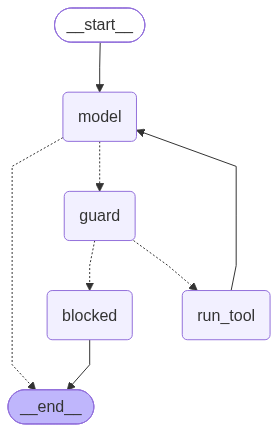

In [3]:
class ToolAgentState(MessagesState):
    tool_steps: int
    blocked: bool
    audit: Annotated[list[str], operator.add]


def call_model(state: ToolAgentState):
    last_message = state['messages'][-1]
    if isinstance(last_message, ToolMessage):
        return {
            'messages': [AIMessage(content=f"已读取工具结果：{last_message.content}")],
            'audit': ['model.final'],
        }

    return {
        'messages': [
            AIMessage(
                content='我需要先查阅学习笔记。',
                tool_calls=[{
                    'name': 'search_learning_notes',
                    'args': {'query': 'LangGraph State'},
                    'id': 'call_notes_1',
                    'type': 'tool_call',
                }],
            )
        ],
        'tool_steps': state.get('tool_steps', 0) + 1,
        'audit': ['model.tool_call:search_learning_notes'],
    }


def validate_tool_call(state: ToolAgentState):
    call = state['messages'][-1].tool_calls[-1]
    name = call['name']
    args = call.get('args', {})
    errors = []
    if name not in tool_names:
        errors.append('工具不在白名单中')
    if name == 'search_learning_notes' and not str(args.get('query', '')).strip():
        errors.append('搜索 query 不能为空')
    if state.get('tool_steps', 0) > 2:
        errors.append('超过工具调用预算')
    blocked = bool(errors)
    audit_message = f"guard.{'blocked' if blocked else 'allowed'}"
    if errors:
        audit_message += ':' + ';'.join(errors)
    return {'blocked': blocked, 'audit': [audit_message]}


def route_after_model(state: ToolAgentState) -> Literal['guard', '__end__']:
    return 'guard' if state['messages'][-1].tool_calls else END


def route_after_guard(state: ToolAgentState) -> Literal['run_tool', 'blocked']:
    return 'blocked' if state['blocked'] else 'run_tool'


def blocked_node(state: ToolAgentState):
    return {
        'messages': [AIMessage(content='工具调用被护栏拒绝，未执行任何工具。')],
        'audit': ['agent.blocked'],
    }


builder = StateGraph(ToolAgentState)
builder.add_node('model', call_model)
builder.add_node('guard', validate_tool_call)
builder.add_node('run_tool', tool_node)
builder.add_node('blocked', blocked_node)
builder.add_edge(START, 'model')
builder.add_conditional_edges('model', route_after_model)
builder.add_conditional_edges('guard', route_after_guard)
builder.add_edge('run_tool', 'model')
builder.add_edge('blocked', END)
tool_agent = builder.compile()
show_graph(tool_agent)

In [4]:
result = tool_agent.invoke({
    'messages': [{'role': 'user', 'content': '解释 LangGraph 的 State'}],
    'tool_steps': 0,
    'blocked': False,
    'audit': [],
})

print('最终消息：', result['messages'][-1].content)
print('审计轨迹：', result['audit'])
assert result['tool_steps'] == 1
assert 'model.tool_call:search_learning_notes' in result['audit']
assert result['messages'][-1].content.startswith('已读取工具结果')

最终消息： 已读取工具结果：笔记结果：LangGraph State -> StateGraph 用节点和边组织状态流程。
审计轨迹： ['model.tool_call:search_learning_notes', 'guard.allowed', 'model.final']


## 3. 验证拒绝路径，而不是只验证成功路径

Guard 节点应该可以独立测试。下面构造一个空 query 的调用，确认它会被拒绝；注意这里没有执行 `ToolNode`。

In [5]:
bad_message = AIMessage(
    content='',
    tool_calls=[{
        'name': 'search_learning_notes',
        'args': {'query': ''},
        'id': 'call_bad_1',
        'type': 'tool_call',
    }],
)
bad_state = {
    'messages': [bad_message],
    'tool_steps': 1,
    'blocked': False,
    'audit': [],
}
guard_result = validate_tool_call(bad_state)
print(guard_result)
assert guard_result['blocked'] is True
assert 'query 不能为空' in guard_result['audit'][0]

{'blocked': True, 'audit': ['guard.blocked:搜索 query 不能为空']}


## 4. 工具 Agent 的工程检查表

- 工具名必须来自白名单。
- 参数先经过 Schema、业务权限和资源范围校验。
- 工具调用次数、总耗时和重试次数必须有上限。
- 高风险写操作要走 `interrupt` 或单独的审批图。
- 工具返回结果要带来源 ID 或请求 ID，不能只返回无上下文的自然语言。
- 审计轨迹和对话消息分开保存，避免把内部控制信息暴露给用户。

## 5. 练习

1. 增加一个 `publish_note` 写工具，并用 `interrupt` 在执行前暂停。
2. 让 fake model 第二次提出计算器调用，观察工具预算如何阻止无限循环。
3. 将 Guard 的字符串错误改成 Pydantic 错误列表。
4. 给每次工具执行增加 `request_id` 和幂等键，模拟重复恢复时不重复提交。
5. 为成功、拒绝、未知工具和超预算分别写一个评测样本。